In [7]:
import pandas as pd
import numpy as np
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score, roc_auc_score
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn import svm
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.wrappers.scikit_learn import KerasClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import GradientBoostingClassifier
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline
import joblib
from sklearn.metrics import confusion_matrix, plot_confusion_matrix, ConfusionMatrixDisplay, plot_roc_curve, RocCurveDisplay, roc_auc_score, classification_report,auc,roc_curve
from matplotlib.colors import ListedColormap
import sklearn.model_selection as model_selection
from sklearn.model_selection import GridSearchCV
import warnings
warnings.filterwarnings("ignore")

In [192]:
d = pd.read_csv('./churn_final.csv')

In [193]:
d.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17391 entries, 0 to 17390
Data columns (total 27 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   Tenure in Months                   17391 non-null  float64
 1   Avg Monthly Long Distance Charges  17391 non-null  float64
 2   Avg Monthly GB Download            17391 non-null  float64
 3   Monthly Charge                     17391 non-null  float64
 4   Total Charges                      17391 non-null  float64
 5   Total Refunds                      17391 non-null  float64
 6   Total Extra Data Charges           17391 non-null  float64
 7   Total Long Distance Charges        17391 non-null  float64
 8   Total Revenue                      17391 non-null  float64
 9   Offer                              17391 non-null  int64  
 10  Phone Service                      17391 non-null  int64  
 11  Multiple Lines                     17391 non-null  int

In [194]:
d.describe()

,Tenure in Months,Avg Monthly Long Distance Charges,Avg Monthly GB Download,Monthly Charge,Total Charges,Total Refunds,Total Extra Data Charges,Total Long Distance Charges,Total Revenue,Offer,...,Device Protection Plan,Premium Tech Support,Streaming TV,Streaming Movies,Streaming Music,Unlimited Data,Contract,Paperless Billing,Payment Method,Customer Status
count,17391.000000,1.739100e+04,17391.000000,17391.000000,17391.000000,17391.000000,17391.000000,17391.000000,17391.000000,17391.000000,...,17391.000000,17391.000000,17391.000000,17391.000000,17391.000000,17391.000000,17391.000000,17391.000000,17391.000000,17391.000000
mean,-0.111573,-4.766186e-03,-0.023198,0.056915,-0.064340,-0.009940,0.001409,-0.073987,-0.072713,1.476971,...,0.333333,0.266057,0.392847,0.395319,0.357024,0.884940,0.638204,0.620206,0.476396,0.595020
std,0.991444,9.996158e-01,1.003830,0.980404,0.977689,0.983614,0.995261,0.968565,0.981621,1.902308,...,0.471418,0.441907,0.488397,0.488933,0.479136,0.319103,0.820720,0.485349,0.607224,0.490902
min,-1.278988,-1.808954e+00,-1.395543,-2.358659,-0.998024,-0.248313,-0.273300,-0.884833,-1.051664,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,-1.075241,-8.211274e-01,-0.703251,-0.738598,-0.866474,-0.248313,-0.273300,-0.826718,-0.897289,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000
50%,-0.341755,5.528789e-15,-0.068650,0.288562,-0.450907,-0.248313,-0.273300,-0.497956,-0.421434,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,1.000000,0.000000,1.000000
75%,0.799225,8.077118e-01,0.046732,0.854221,0.526760,-0.248313,-0.273300,0.388012,0.519965,3.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
max,1.614210,1.820734e+00,3.392809,1.767609,2.826236,6.052581,5.702034,3.325798,3.122149,5.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,2.000000,1.000000,2.000000,1.000000


In [203]:
d['Customer ID'].isna().sum()

0

In [202]:

# Create a mask to identify the rows with NaN values in the Customer ID column
mask = d['Customer ID'].isnull()

# Generate a list of unique customer IDs from the original dataset
unique_customer_ids = d['Customer ID'].dropna().unique()

# Generate a random sample of customer IDs with the same length as the number of NaN values
random_customer_ids = np.random.choice(unique_customer_ids, size=mask.sum())

# Replace the NaN values in the Customer ID column with the random sample
d.loc[mask, 'Customer ID'] = random_customer_ids


In [11]:
d.shape

(17391, 27)

In [18]:
X = d.iloc[:,:-2]

In [16]:
y = d['Customer Status']

### Splitting into train and test data

In [20]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.30, random_state=42, train_size=0.70)

### Splitting test data further to get validation set

In [21]:
X_val, X_test, y_val, y_test = train_test_split(X_test, y_test, test_size=0.50, random_state=1, train_size=0.50)

### Hypertuning

In [24]:
svm_model = SVC(kernel='linear')
param_grid = {
    'C': [0.1, 1, 10],
    'kernel': ['linear', 'poly', 'rbf', 'sigmoid'],
    'gamma': ['scale', 'auto']
}
grid_search = GridSearchCV(estimator=svm_model, param_grid=param_grid)
grid_search.fit(X_train, y_train)
best_params = grid_search.best_params_
best_model = SVC(**best_params)
best_model.fit(X_train, y_train)
y_pred = best_model.predict(X_test)

svm_accuracy = accuracy_score(y_test, y_pred)
svm_f1 = f1_score(y_test, y_pred)
svm_precision = precision_score(y_test, y_pred)
svm_recall = recall_score(y_test, y_pred)
svm_auc_roc = roc_auc_score(y_test, y_pred)

print('Best hyperparameters:', best_params)
print('Accuracy:', svm_accuracy)
print('F1 score:', svm_f1)
print('Precision:', svm_precision)
print('Recall:', svm_recall)
print('AUC-ROC:', svm_auc_roc)

Best hyperparameters: {'C': 10, 'gamma': 'scale', 'kernel': 'rbf'}
Accuracy: 0.8363357608279034
F1 score: 0.8649161657703259
Precision: 0.8651898734177215
Recall: 0.8646426312460468
AUC-ROC: 0.8287220938331402


In [25]:
rf_model = RandomForestClassifier(random_state=0)
param_grid = {
    'n_estimators': [50, 100, 150],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}
grid_search = GridSearchCV(rf_model, param_grid=param_grid, n_jobs=-1)
grid_search.fit(X_train, y_train)
best_params = grid_search.best_params_
best_rf_model = grid_search.best_estimator_
y_pred = best_rf_model.predict(X_test)

rf_accuracy = accuracy_score(y_test, y_pred)
rf_f1 = f1_score(y_test, y_pred)
rf_precision = precision_score(y_test, y_pred)
rf_recall = recall_score(y_test, y_pred)
rf_auc_roc = roc_auc_score(y_test, y_pred)

print('Best hyperparameters:', best_params)
print('Accuracy:', rf_accuracy)
print('F1 score:', rf_f1)
print('Precision:', rf_precision)
print('Recall:', rf_recall)
print('AUC-ROC:', rf_auc_roc)

Best hyperparameters: {'max_depth': 20, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 150}
Accuracy: 0.9697201993100805
F1 score: 0.9747684445863941
Precision: 0.984516129032258
Recall: 0.9652118912080961
AUC-ROC: 0.9709327938530753


In [26]:
def create_model(optimizer='adam', activation='relu'):
    model = tf.keras.models.Sequential([
        tf.keras.layers.Dense(64, activation=activation, input_shape=(X_train.shape[1],)),
        tf.keras.layers.Dense(32, activation=activation),
        tf.keras.layers.Dense(1, activation='tanh')
    ])
    model.compile(optimizer=optimizer, loss='binary_crossentropy', metrics=['accuracy'])
    return model


nn_classifier = KerasClassifier(build_fn=create_model, epochs=10, batch_size=32, validation_split=0.2)
param_grid = {
    'optimizer': ['adam', 'sgd'],
    'activation': ['relu', 'tanh', 'sigmoid']
}
grid_search = GridSearchCV(estimator=nn_classifier, param_grid=param_grid)
grid_search.fit(X_train, y_train)
best_params = grid_search.best_params_
nn_model = create_model(optimizer=best_params['optimizer'], activation=best_params['activation'])
nn_model.fit(X_train, y_train, epochs=10, batch_size=32, validation_split=0.2)
y_pred = nn_model.predict(X_test)
y_pred_discrete = (y_pred > 0.5).astype(int)

nn_accuracy = accuracy_score(y_test, y_pred_discrete)
nn_f1 = f1_score(y_test, y_pred_discrete)
nn_precision = precision_score(y_test, y_pred_discrete)
nn_recall = recall_score(y_test, y_pred_discrete)
nn_auc_roc = roc_auc_score(y_test, y_pred)

print('Best hyperparameters:', best_params)
print('Accuracy:', nn_accuracy)
print('F1 score:', nn_f1)
print('Precision:', nn_precision)
print('Recall:', nn_recall)
print('AUC-ROC:', nn_auc_roc)

Epoch 1/10


2023-06-18 21:18:13.513167: W tensorflow/core/platform/profile_utils/cpu_utils.cc:128] Failed to get CPU frequency: 0 Hz


244/244 [==============================] - 0s 810us/step - loss: 0.6106 - accuracy: 0.7069 - val_loss: 0.5116 - val_accuracy: 0.7413
Epoch 2/10
244/244 [==============================] - 0s 556us/step - loss: 0.4942 - accuracy: 0.7635 - val_loss: 0.4717 - val_accuracy: 0.7675
Epoch 3/10
244/244 [==============================] - 0s 554us/step - loss: 0.4767 - accuracy: 0.7738 - val_loss: 0.4756 - val_accuracy: 0.7613
Epoch 4/10
244/244 [==============================] - 0s 553us/step - loss: 0.4568 - accuracy: 0.7834 - val_loss: 0.4556 - val_accuracy: 0.7870
Epoch 5/10
244/244 [==============================] - 0s 548us/step - loss: 0.4694 - accuracy: 0.7769 - val_loss: 0.4394 - val_accuracy: 0.7911
Epoch 6/10
244/244 [==============================] - 0s 548us/step - loss: 0.4506 - accuracy: 0.7892 - val_loss: 0.4340 - val_accuracy: 0.7936
Epoch 7/10
244/244 [==============================] - 0s 552us/step - loss: 0.4488 - accuracy: 0.7923 - val_loss: 0.5577 - val_accuracy: 0.6956
Epo

Epoch 5/10
244/244 [==============================] - 0s 458us/step - loss: 0.4731 - accuracy: 0.7810 - val_loss: 0.4656 - val_accuracy: 0.7705
Epoch 6/10
244/244 [==============================] - 0s 457us/step - loss: 0.4550 - accuracy: 0.7878 - val_loss: 0.4674 - val_accuracy: 0.7864
Epoch 7/10
244/244 [==============================] - 0s 461us/step - loss: 0.4592 - accuracy: 0.7874 - val_loss: 0.4470 - val_accuracy: 0.7849
Epoch 8/10
244/244 [==============================] - 0s 455us/step - loss: 0.4517 - accuracy: 0.7931 - val_loss: 0.4448 - val_accuracy: 0.7895
Epoch 9/10
244/244 [==============================] - 0s 453us/step - loss: 0.4501 - accuracy: 0.7874 - val_loss: 0.4669 - val_accuracy: 0.7895
Epoch 10/10
77/77 [==============================] - 0s 326us/step - loss: 0.4612 - accuracy: 0.7988
Epoch 1/10
244/244 [==============================] - 0s 711us/step - loss: 0.5864 - accuracy: 0.7072 - val_loss: 0.5149 - val_accuracy: 0.7526
Epoch 2/10
244/244 [===============

Epoch 9/10
244/244 [==============================] - 0s 514us/step - loss: 0.5752 - accuracy: 0.7395 - val_loss: 0.5485 - val_accuracy: 0.6632
Epoch 10/10
77/77 [==============================] - 0s 306us/step - loss: 0.4793 - accuracy: 0.7811
Epoch 1/10
244/244 [==============================] - 0s 746us/step - loss: 0.8642 - accuracy: 0.6502 - val_loss: 0.6697 - val_accuracy: 0.6273
Epoch 2/10
244/244 [==============================] - 0s 523us/step - loss: 0.5832 - accuracy: 0.7099 - val_loss: 0.4945 - val_accuracy: 0.7726
Epoch 3/10
244/244 [==============================] - 0s 515us/step - loss: 0.4751 - accuracy: 0.7828 - val_loss: 0.4515 - val_accuracy: 0.7849
Epoch 4/10
244/244 [==============================] - 0s 518us/step - loss: 0.7505 - accuracy: 0.7127 - val_loss: 0.7113 - val_accuracy: 0.6956
Epoch 5/10
244/244 [==============================] - 0s 513us/step - loss: 0.5256 - accuracy: 0.7502 - val_loss: 0.4959 - val_accuracy: 0.7669
Epoch 6/10
244/244 [===============

244/244 [==============================] - 0s 459us/step - loss: 0.6704 - accuracy: 0.7262 - val_loss: 0.5079 - val_accuracy: 0.7562
Epoch 3/10
244/244 [==============================] - 0s 449us/step - loss: 0.5183 - accuracy: 0.7679 - val_loss: 0.7811 - val_accuracy: 0.7582
Epoch 4/10
244/244 [==============================] - 0s 444us/step - loss: 0.5066 - accuracy: 0.7633 - val_loss: 0.4706 - val_accuracy: 0.7829
Epoch 5/10
244/244 [==============================] - 0s 445us/step - loss: 0.4926 - accuracy: 0.7733 - val_loss: 0.4659 - val_accuracy: 0.7793
Epoch 6/10
244/244 [==============================] - 0s 450us/step - loss: 0.4757 - accuracy: 0.7738 - val_loss: 0.4546 - val_accuracy: 0.7859
Epoch 7/10
244/244 [==============================] - 0s 447us/step - loss: 0.4672 - accuracy: 0.7869 - val_loss: 0.4651 - val_accuracy: 0.7813
Epoch 8/10
244/244 [==============================] - 0s 449us/step - loss: 0.8949 - accuracy: 0.6981 - val_loss: 0.5414 - val_accuracy: 0.7094
Epo

Epoch 6/10
244/244 [==============================] - 0s 521us/step - loss: 9.0411 - accuracy: 0.4139 - val_loss: 9.2328 - val_accuracy: 0.4014
Epoch 7/10
244/244 [==============================] - 0s 518us/step - loss: 9.0411 - accuracy: 0.4139 - val_loss: 9.2328 - val_accuracy: 0.4014
Epoch 8/10
244/244 [==============================] - 0s 523us/step - loss: 9.0411 - accuracy: 0.4139 - val_loss: 9.2328 - val_accuracy: 0.4014
Epoch 9/10
244/244 [==============================] - 0s 512us/step - loss: 9.0411 - accuracy: 0.4139 - val_loss: 9.2328 - val_accuracy: 0.4014
Epoch 10/10
77/77 [==============================] - 0s 305us/step - loss: 9.4894 - accuracy: 0.3848
Epoch 1/10
244/244 [==============================] - 0s 749us/step - loss: 9.1362 - accuracy: 0.4077 - val_loss: 9.2328 - val_accuracy: 0.4014
Epoch 2/10
244/244 [==============================] - 0s 530us/step - loss: 9.1362 - accuracy: 0.4077 - val_loss: 9.2328 - val_accuracy: 0.4014
Epoch 3/10
244/244 [===============

Epoch 10/10
77/77 [==============================] - 0s 303us/step - loss: 9.4894 - accuracy: 0.3848
Epoch 1/10
244/244 [==============================] - 0s 694us/step - loss: 0.6623 - accuracy: 0.5955 - val_loss: 0.6297 - val_accuracy: 0.6715
Epoch 2/10
244/244 [==============================] - 0s 458us/step - loss: 0.6099 - accuracy: 0.6809 - val_loss: 0.5855 - val_accuracy: 0.7130
Epoch 3/10
244/244 [==============================] - 0s 449us/step - loss: 0.5711 - accuracy: 0.7366 - val_loss: 0.5537 - val_accuracy: 0.7269
Epoch 4/10
244/244 [==============================] - 0s 448us/step - loss: 0.5399 - accuracy: 0.7506 - val_loss: 0.5310 - val_accuracy: 0.7346
Epoch 5/10
244/244 [==============================] - 0s 448us/step - loss: 0.5155 - accuracy: 0.7616 - val_loss: 0.5235 - val_accuracy: 0.7248
Epoch 6/10
244/244 [==============================] - 0s 446us/step - loss: 0.5011 - accuracy: 0.7682 - val_loss: 0.4878 - val_accuracy: 0.7644
Epoch 7/10
244/244 [===============

In [27]:
max_n_neighbours = 10

param_grid = {
    'n_neighbors': range(1, max_n_neighbours),
    'weights': ['uniform', 'distance'],
    'metric': ['euclidean', 'manhattan']
}
knn_model = KNeighborsClassifier()
grid_search = GridSearchCV(knn_model, param_grid, cv=5)
grid_search.fit(X_train, y_train)
best_knn_model = KNeighborsClassifier(**grid_search.best_params_)
best_knn_model.fit(X_train, y_train)
y_pred = best_knn_model.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
auc_roc = roc_auc_score(y_test, y_pred)

print("Best score:", grid_search.best_score_)
print("Best hyperparameters:", grid_search.best_params_)
print('Accuracy:', accuracy)
print('F1 score:', f1)
print('Precision:', precision)
print('Recall:', recall)
print('AUC-ROC:', auc_roc)

Best score: 0.9199042989544086
Best hyperparameters: {'metric': 'euclidean', 'n_neighbors': 1, 'weights': 'uniform'}
Accuracy: 0.9532387888079724
F1 score: 0.9605688429217841
Precision: 0.9821546596166556
Recall: 0.9399114484503479
AUC-ROC: 0.9568234285053296


In [28]:
param_grid = {
    'max_depth': [3, 5, 7, None],
    'max_features': ['sqrt', 'log2', None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'criterion': ['gini', 'entropy']
}
grid_search = GridSearchCV(estimator=DecisionTreeClassifier(random_state=0),param_grid=param_grid,n_jobs=-1)
grid_search.fit(X_train, y_train)
best_params = grid_search.best_params_
dt_model = DecisionTreeClassifier(random_state=0, **best_params)
dt_model.fit(X_train, y_train)
y_pred = dt_model.predict(X_test)

dt_accuracy = accuracy_score(y_test, y_pred)
dt_f1 = f1_score(y_test, y_pred)
dt_precision = precision_score(y_test, y_pred)
dt_recall = recall_score(y_test, y_pred)
dt_auc_roc = roc_auc_score(y_test, y_pred)

print("Best hyperparameters:", best_params)
print('Accuracy:', dt_accuracy)
print('F1 score:', dt_f1)
print('Precision:', dt_precision)
print('Recall:', dt_recall)
print('AUC-ROC:', dt_auc_roc)

Best hyperparameters: {'criterion': 'gini', 'max_depth': None, 'max_features': None, 'min_samples_leaf': 1, 'min_samples_split': 2}
Accuracy: 0.9509390571100038
F1 score: 0.9586028460543338
Precision: 0.9808074123097287
Recall: 0.937381404174573
AUC-ROC: 0.9545856437215279


In [29]:
param_grid = {'n_estimators': [50, 100, 150], 
              'max_depth': [None, 5, 7]}
gb_model = GradientBoostingClassifier()
grid_search = GridSearchCV(gb_model, param_grid)
grid_search.fit(X_train, y_train)
best_gb_model = grid_search.best_estimator_
y_pred = best_gb_model.predict(X_test)

gb_accuracy = accuracy_score(y_test, y_pred)
gb_f1 = f1_score(y_test, y_pred)
gb_precision = precision_score(y_test, y_pred)
gb_recall = recall_score(y_test, y_pred)
gb_auc_roc = roc_auc_score(y_test, y_pred)

print("Best hyperparameters:", grid_search.best_params_)
print('Accuracy:', gb_accuracy)
print('F1 score:', gb_f1)
print('Precision:', gb_precision)
print('Recall:', gb_recall)
print('AUC-ROC:', gb_auc_roc)

Best hyperparameters: {'max_depth': None, 'n_estimators': 150}
Accuracy: 0.9513223457263319
F1 score: 0.9589660743134086
Precision: 0.9801849405548216
Recall: 0.9386464263124604
AUC-ROC: 0.9547317734675143


### Training the models using the best parameters

### Support Vector Machine

In [30]:
svm_model = SVC(C=10, gamma='scale', kernel='rbf')
svm_model.fit(X_train, y_train)
y_pred = svm_model.predict(X_test)

svm_accuracy = accuracy_score(y_test, y_pred)
svm_f1 = f1_score(y_test, y_pred)
svm_precision = precision_score(y_test, y_pred)
svm_recall = recall_score(y_test, y_pred)
svm_auc_roc = roc_auc_score(y_test, y_pred)
print('Accuracy:', svm_accuracy)
print('F1 score:', svm_f1)
print('Precision:', svm_precision)
print('Recall:', svm_recall)
print('AUC-ROC:', svm_auc_roc)

Accuracy: 0.8363357608279034
F1 score: 0.8649161657703259
Precision: 0.8651898734177215
Recall: 0.8646426312460468
AUC-ROC: 0.8287220938331402


### Random Forest Model

In [31]:
rf_model = RandomForestClassifier(max_depth= 20, min_samples_leaf= 1, min_samples_split= 2, n_estimators=150)
rf_model.fit(X_train, y_train)
y_pred = rf_model.predict(X_test)

rf_accuracy = accuracy_score(y_test, y_pred)
rf_f1 = f1_score(y_test, y_pred)
rf_precision = precision_score(y_test, y_pred)
rf_recall = recall_score(y_test, y_pred)
rf_auc_roc = roc_auc_score(y_test, y_pred)

print('Accuracy:', rf_accuracy)
print('F1 score:', rf_f1)
print('Precision:', rf_precision)
print('Recall:', rf_recall)
print('AUC-ROC:', rf_auc_roc)

Accuracy: 0.9712533537753929
F1 score: 0.9760765550239234
Precision: 0.9845559845559846
Recall: 0.967741935483871
AUC-ROC: 0.9721978159909628


### Neural Network Model

In [32]:
nn_model = tf.keras.models.Sequential([
    tf.keras.layers.Dense(64, activation='relu', input_shape=(X_train.shape[1],)),
    tf.keras.layers.Dense(32, activation='relu'),
    tf.keras.layers.Dense(1, activation='relu') # modified to output binary classification
])
nn_model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
history = nn_model.fit(X_train, y_train, epochs=10, batch_size=32, validation_split=0.2)
y_pred = nn_model.predict(X_test)
y_pred_discrete = (y_pred > 0.5).astype(int)  # convert predictions to binary values

nn_accuracy = accuracy_score(y_test, y_pred_discrete)
nn_f1 = f1_score(y_test, y_pred_discrete)
nn_precision = precision_score(y_test, y_pred_discrete)
nn_recall = recall_score(y_test, y_pred_discrete)
nn_auc_roc = roc_auc_score(y_test, y_pred)

print('Accuracy:', nn_accuracy)
print('F1 score:', nn_f1)
print('Precision:', nn_precision)
print('Recall:', nn_recall)
print('AUC-ROC:', nn_auc_roc)

Epoch 1/10
305/305 [==============================] - 0s 705us/step - loss: 1.5295 - accuracy: 0.6845 - val_loss: 0.5481 - val_accuracy: 0.7614
Epoch 2/10
305/305 [==============================] - 0s 516us/step - loss: 0.5553 - accuracy: 0.7647 - val_loss: 0.4894 - val_accuracy: 0.7758
Epoch 3/10
305/305 [==============================] - 0s 517us/step - loss: 0.6201 - accuracy: 0.7519 - val_loss: 0.4647 - val_accuracy: 0.7823
Epoch 4/10
305/305 [==============================] - 0s 522us/step - loss: 0.5291 - accuracy: 0.7690 - val_loss: 0.4981 - val_accuracy: 0.7852
Epoch 5/10
305/305 [==============================] - 0s 509us/step - loss: 0.5065 - accuracy: 0.7795 - val_loss: 0.4700 - val_accuracy: 0.7930
Epoch 6/10
305/305 [==============================] - 0s 515us/step - loss: 0.5077 - accuracy: 0.7849 - val_loss: 0.4826 - val_accuracy: 0.7704
Epoch 7/10
305/305 [==============================] - 0s 513us/step - loss: 0.4999 - accuracy: 0.7811 - val_loss: 0.4645 - val_accuracy:

### K-Nearest Neighbour

In [33]:
knn_model = KNeighborsClassifier(metric='euclidean',n_neighbors=1, weights='uniform')
knn_model.fit(X_train, y_train)
y_pred = knn_model.predict(X_test)

knn_accuracy = accuracy_score(y_test, y_pred)
knn_f1 = f1_score(y_test, y_pred)
knn_precision = precision_score(y_test, y_pred)
knn_recall = recall_score(y_test, y_pred)
knn_auc_roc = roc_auc_score(y_test, y_pred)

print('Accuracy:', knn_accuracy)
print('F1 score:', knn_f1)
print('Precision:', knn_precision)
print('Recall:', knn_recall)
print('AUC-ROC:', knn_auc_roc)

Accuracy: 0.9532387888079724
F1 score: 0.9605688429217841
Precision: 0.9821546596166556
Recall: 0.9399114484503479
AUC-ROC: 0.9568234285053296


### Decision Tree

In [34]:
dt_model = DecisionTreeClassifier(criterion= 'gini', max_depth= None, max_features= None, 
                                  min_samples_leaf=1, min_samples_split=2)
dt_model.fit(X_train, y_train)
y_pred = dt_model.predict(X_test)

dt_accuracy = accuracy_score(y_test, y_pred)
dt_f1 = f1_score(y_test, y_pred)
dt_precision = precision_score(y_test, y_pred)
dt_recall = recall_score(y_test, y_pred)
dt_auc_roc = roc_auc_score(y_test, y_pred)

print('Accuracy:', dt_accuracy)
print('F1 score:', dt_f1)
print('Precision:', dt_precision)
print('Recall:', dt_recall)
print('AUC-ROC:', dt_auc_roc)

Accuracy: 0.9559218091222691
F1 score: 0.9629868039909881
Precision: 0.9803407601572739
Recall: 0.946236559139785
AUC-ROC: 0.9585268398811765


### Gradient Booster

In [35]:
gb_model = GradientBoostingClassifier(max_depth= None, n_estimators=150)
gb_model.fit(X_train, y_train)
y_pred = gb_model.predict(X_test)

gb_accuracy = accuracy_score(y_test, y_pred)
gb_f1 = f1_score(y_test, y_pred)
gb_precision = precision_score(y_test, y_pred)
gb_recall = recall_score(y_test, y_pred)
gb_auc_roc = roc_auc_score(y_test, y_pred)

print('Accuracy:', gb_accuracy)
print('F1 score:', gb_f1)
print('Precision:', gb_precision)
print('Recall:', gb_recall)
print('AUC-ROC:', gb_auc_roc)

Accuracy: 0.9536220774243005
F1 score: 0.9609803289261529
Precision: 0.9802631578947368
Recall: 0.9424414927261227
AUC-ROC: 0.9566293066743453


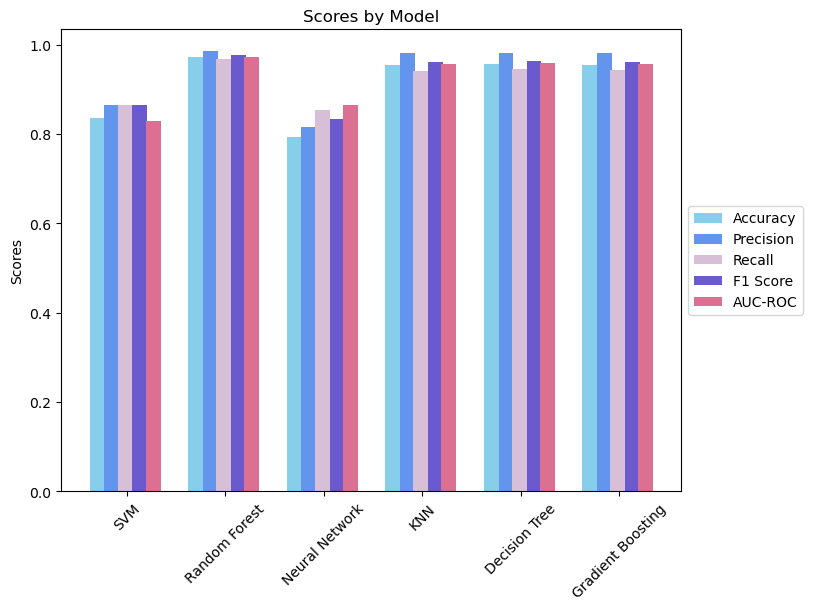

In [36]:
models = ['SVM', 'Random Forest', 'Neural Network', 'KNN', 'Decision Tree', 'Gradient Boosting']
accuracy = [svm_accuracy, rf_accuracy, nn_accuracy, knn_accuracy, dt_accuracy, gb_accuracy]
precision = [svm_precision, rf_precision, nn_precision, knn_precision, dt_precision, gb_precision]
recall = [svm_recall, rf_recall, nn_recall, knn_recall, dt_recall, gb_recall]
f1 = [svm_f1,rf_f1,nn_f1,knn_f1,dt_f1, gb_f1]
auc_roc=[svm_auc_roc, rf_auc_roc, nn_auc_roc, knn_auc_roc, dt_auc_roc, gb_auc_roc]

x = np.arange(len(models))
width = 0.15
fig, ax = plt.subplots(figsize=(8,6))
rects1 = ax.bar(x - 2.0*width, accuracy, width, label='Accuracy', color='skyblue')
rects2 = ax.bar(x - 1.0*width, precision, width, label='Precision',color='cornflowerblue')
rects3 = ax.bar(x - 0.1*width, recall, width, label='Recall', color='thistle')
rects4 = ax.bar(x + 0.9*width, f1, width, label='F1 Score', color='slateblue')
rects5 = ax.bar(x + 1.8*width, auc_roc, width, label='AUC-ROC', color='palevioletred')
ax.set_ylabel('Scores')
ax.set_title('Scores by Model')
ax.set_xticks(x)
ax.set_xticklabels(models)
ax.legend(loc='center left', bbox_to_anchor=(1, 0.5))
plt.xticks(rotation=45)
plt.show()

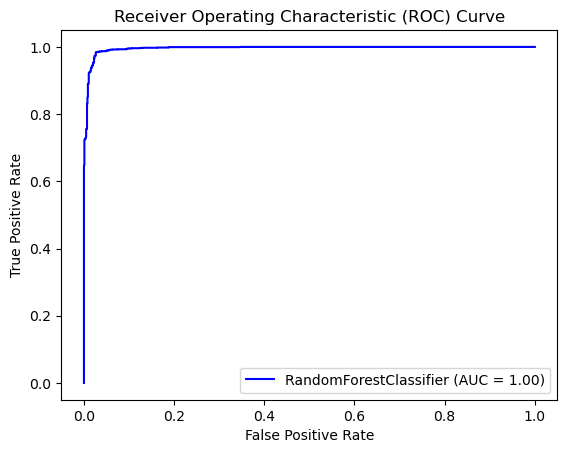

In [279]:
from sklearn.metrics import roc_curve, roc_auc_score

RocCurveDisplay.from_estimator(rf_model,X_test, y_test, color='blue')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.show()

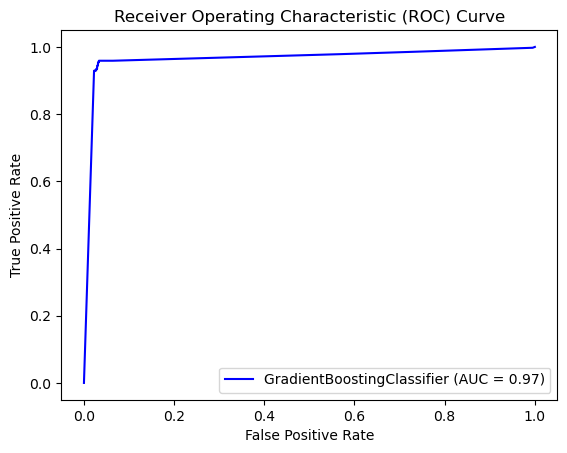

In [278]:
RocCurveDisplay.from_estimator(gb_model,X_test, y_test, color='blue')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.show()

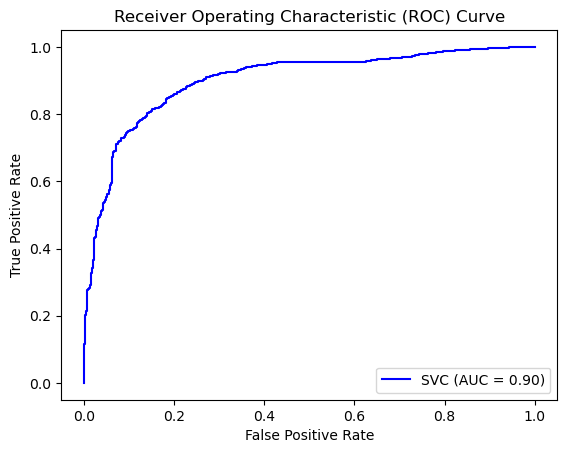

In [277]:
RocCurveDisplay.from_estimator(svm_model,X_test, y_test, color='blue') 
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.show()

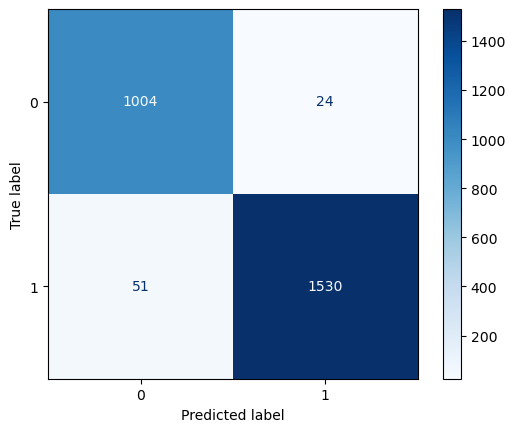

In [276]:
plot_confusion_matrix(rf_model,X_test, y_test, cmap = 'Blues') # Use `plot_confusion_matrix` to generate graphical output
plt.show()

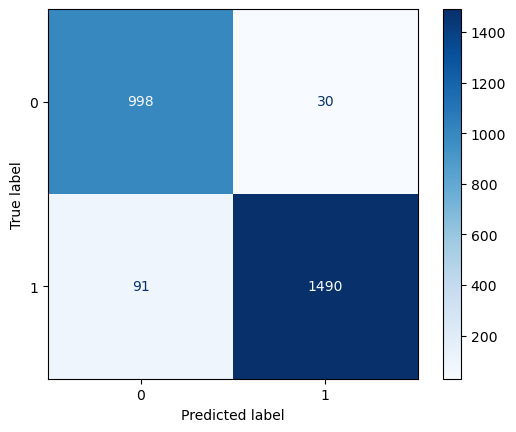

In [274]:
plot_confusion_matrix(gb_model,X_test, y_test, cmap = 'Blues') # Use `plot_confusion_matrix` to generate graphical output
plt.show()

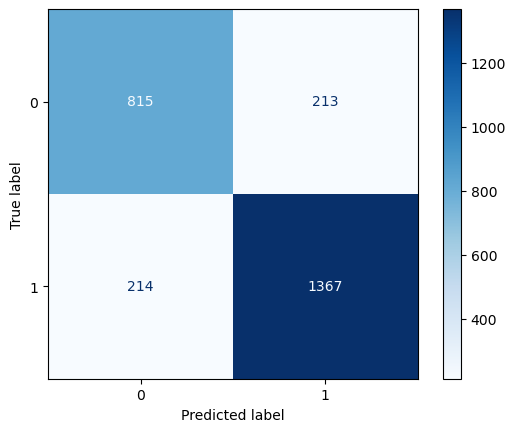

In [275]:
plot_confusion_matrix(svm_model,X_test, y_test, cmap = 'Blues') # Use `plot_confusion_matrix` to generate graphical output
plt.show()

In [37]:
joblib.dump(rf_model, 'rf_model.joblib')

['rf_model.joblib']

In [38]:
rf = joblib.load('rf_model.joblib')

In [210]:

# Get the indices of the validation set
val_indices = X_val.index

# Create a new dataframe with the 'Customer ID' column and predictions
df_val = pd.DataFrame({'Customer ID': d.loc[val_indices, 'Customer ID'], 'Customer Status': d.loc[val_indices, 'Customer Status']})

# Optionally, reset the index of df_val
# df_val.reset_index(drop=True, inplace=True)


In [211]:
# Predict probabilities for the validation set
proba_val = rf.predict_proba(X_val)[:, 1]

# Assign predicted probabilities to 'predictions' column in df_val
df_val['predictions'] = proba_val



In [212]:
df_val['predictions'] = rf.predict_proba(X_val)


In [213]:
threshold = 0.5
df_val['churned'] = df_val['predictions'] >= threshold

In [214]:
# Customers who have churned
churned_customers = df_val[df_val['churned'] == True]

# Customers who have not churned
not_churned_customers = df_val[df_val['churned'] == False]


In [171]:
df_val[['predictions','churned']].head(20)

,predictions,churned
2882,0.993333,True
2602,0.045778,False
2614,0.040000,False
1981,0.056389,False
16208,0.942440,True
14730,0.950344,True
2518,0.849248,True
17379,0.951678,True
2974,0.046667,False
1713,0.026667,False


In [172]:
churn_summary = df_val.groupby('churned').size()


In [173]:
churn_summary

churned
False    1518
True     1091
dtype: int64

In [221]:
df_val.drop('Customer Status', axis=1, inplace=True)

In [222]:
merged_df = d.merge(df_val, on='Customer ID')

In [225]:
merged_df

,Tenure in Months,Avg Monthly Long Distance Charges,Avg Monthly GB Download,Monthly Charge,Total Charges,Total Refunds,Total Extra Data Charges,Total Long Distance Charges,Total Revenue,Offer,...,Streaming Movies,Streaming Music,Unlimited Data,Contract,Paperless Billing,Payment Method,Customer Status,Customer ID,predictions,churned
0,-0.789997,1.778149e-01,-1.280161,1.102599,-0.460063,-0.248313,-0.273300,-0.457641,-0.500827,4,...,1,0,1,0,1,0,0,7858-GTZSP,0.971880,True
1,-0.830746,-4.943221e-01,-0.068650,0.735641,-0.535503,-0.248313,4.108612,-0.619064,-0.569800,4,...,1,1,0,0,1,0,1,7858-GTZSP,0.971880,True
2,-0.952994,-6.410510e-01,2.700518,0.186006,-0.754142,-0.248313,-0.273300,-0.706555,-0.806980,5,...,1,1,1,0,1,1,1,3722-WPXTK,0.969491,True
3,-0.260256,1.299031e+00,0.046732,0.588217,-0.092818,-0.248313,-0.273300,0.434208,0.053184,0,...,0,0,1,0,0,0,1,3722-WPXTK,0.969491,True
4,-0.626999,-1.805249e+00,-0.068650,0.610651,-0.357595,-0.248313,-0.273300,-0.863547,-0.539724,4,...,0,0,1,1,1,1,1,3722-WPXTK,0.969491,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8656,1.491962,5.528789e-15,0.912097,-0.089612,0.875096,-0.248313,-0.273300,-0.884833,0.428977,0,...,1,1,1,1,1,1,1,9955-QOPOY,0.020000,False
8657,1.614210,1.519866e+00,0.219805,1.293288,2.311201,-0.248313,-0.273300,3.021333,2.719120,1,...,1,1,1,2,0,1,1,9958-MEKUC,0.020000,False
8658,-0.423253,-6.832912e-01,-0.530178,0.689171,-0.179466,-0.248313,-0.273300,-0.463855,-0.280726,4,...,1,1,1,0,1,0,0,9992-RRAMN,0.943659,True
8659,-0.423253,-6.832912e-01,-0.530178,0.689171,-0.179466,-0.248313,-0.273300,-0.463855,-0.280726,4,...,1,1,1,0,1,0,0,9992-RRAMN,0.943659,True


In [228]:
threshold = 0.5  # Set the threshold probability
churned_customers = merged_df[merged_df['predictions'] >= threshold]

In [229]:
churned = pd.DataFrame(churned_customers)

In [232]:
churned.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 4533 entries, 0 to 8659
Data columns (total 29 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   Tenure in Months                   4533 non-null   float64
 1   Avg Monthly Long Distance Charges  4533 non-null   float64
 2   Avg Monthly GB Download            4533 non-null   float64
 3   Monthly Charge                     4533 non-null   float64
 4   Total Charges                      4533 non-null   float64
 5   Total Refunds                      4533 non-null   float64
 6   Total Extra Data Charges           4533 non-null   float64
 7   Total Long Distance Charges        4533 non-null   float64
 8   Total Revenue                      4533 non-null   float64
 9   Offer                              4533 non-null   int64  
 10  Phone Service                      4533 non-null   int64  
 11  Multiple Lines                     4533 non-null   int64

In [234]:
# Assuming you have a dataframe named 'churned_customers' with relevant columns
# Calculate monthly revenue
churned['Monthly Revenue'] = churned['Total Revenue'] / churned['Tenure in Months']

# Calculate churn rate
total_customers = len(churned_customers)
churned_customers_count = len(churned_customers[churned_customers['churned'] == 1])
churn_rate = churned_customers_count / total_customers

# Calculate average customer lifespan
average_lifespan = 1 / churn_rate

# Set discount rate (e.g., 0.1 for 10%)
discount_rate = 0.1

# Calculate CLV
churned['CLV'] = churned['Monthly Revenue'] * average_lifespan / (1 + discount_rate - churn_rate)


In [235]:
churned

,Tenure in Months,Avg Monthly Long Distance Charges,Avg Monthly GB Download,Monthly Charge,Total Charges,Total Refunds,Total Extra Data Charges,Total Long Distance Charges,Total Revenue,Offer,...,Unlimited Data,Contract,Paperless Billing,Payment Method,Customer Status,Customer ID,predictions,churned,Monthly Revenue,CLV
0,-0.789997,0.177815,-1.280161,1.102599,-0.460063,-0.248313,-0.273300,-0.457641,-0.500827,4,...,1,0,1,0,0,7858-GTZSP,0.971880,True,0.633961,6.339606
1,-0.830746,-0.494322,-0.068650,0.735641,-0.535503,-0.248313,4.108612,-0.619064,-0.569800,4,...,0,0,1,0,1,7858-GTZSP,0.971880,True,0.685890,6.858903
2,-0.952994,-0.641051,2.700518,0.186006,-0.754142,-0.248313,-0.273300,-0.706555,-0.806980,5,...,1,0,1,1,1,3722-WPXTK,0.969491,True,0.846784,8.467844
3,-0.260256,1.299031,0.046732,0.588217,-0.092818,-0.248313,-0.273300,0.434208,0.053184,0,...,1,0,0,0,1,3722-WPXTK,0.969491,True,-0.204351,-2.043509
4,-0.626999,-1.805249,-0.068650,0.610651,-0.357595,-0.248313,-0.273300,-0.863547,-0.539724,4,...,1,1,1,1,1,3722-WPXTK,0.969491,True,0.860804,8.608041
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8653,-0.952994,-0.253479,-1.107088,0.902294,-0.624247,-0.248313,-0.273300,-0.650956,-0.687811,5,...,1,0,0,0,0,9940-HPQPG,0.985160,True,0.721737,7.217372
8654,-0.952994,-0.253479,-1.107088,0.902294,-0.624247,-0.248313,-0.273300,-0.650956,-0.687811,5,...,1,0,0,0,0,9940-HPQPG,0.985160,True,0.721737,7.217372
8655,-0.952994,-0.253479,-1.107088,0.902294,-0.624247,-0.248313,-0.273300,-0.650956,-0.687811,5,...,1,0,0,0,0,9940-HPQPG,0.985160,True,0.721737,7.217372
8658,-0.423253,-0.683291,-0.530178,0.689171,-0.179466,-0.248313,-0.273300,-0.463855,-0.280726,4,...,1,0,1,0,0,9992-RRAMN,0.943659,True,0.663257,6.632569


In [236]:
customer_with_highest_clv = churned.loc[churned['CLV'].idxmax()]


In [238]:
customer_with_highest_clv[['Customer ID', 'CLV']]

Customer ID    9750-BOOHV
CLV            466.567701
Name: 1493, dtype: object

In [260]:
top_5_customer = churned.nlargest(5, 'CLV')
top_5_customer[['Customer ID', 'CLV']]

,Customer ID,CLV
1493,9750-BOOHV,466.567701
4352,6878-GGDWG,442.494407
3404,7254-IQWOZ,428.728114
4244,3298-QEICA,252.224770
2441,8123-QBNAZ,201.384552


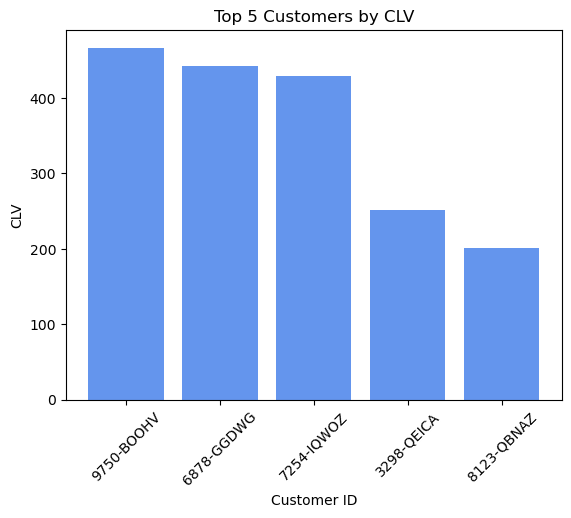

In [262]:
import matplotlib.pyplot as plt

# Extract the top 5 customers
top_5_customers = pd.DataFrame(top_5_customer)
top_5 = top_5_customers['Customer ID']
top_5_clv = top_5_customers['CLV']

# Create a bar plot
plt.bar(top_5, top_5_clv, color='cornflowerblue')
plt.xlabel('Customer ID')
plt.ylabel('CLV')
plt.title('Top 5 Customers by CLV')
plt.xticks(rotation=45)

# Display the plot
plt.show()
